# Data Exploration Report - for "RAGuardianNews" Prototype
IDS 570 - Text as Data\
Peter de Guzman ped19\
02/26/26

# Table of Contents
* [Project Overview](#project-overview)
    * [Description of Data](#description-of-data)
* [Data Pipeline and Application Functionality](#data-pipeline-and-application-functionality)
    * [Data Pre-processing Procedures](#data-pre-processing-procedures)
* [Metadata Analysis](#metadata-analysis)
* [Measures of Lexican Distinctiveness, Similarity, and Syntactic Complexity](#measures-of-lexical-distinctiveness-similarity-and-syntactic-complexity)
    * [TF-IDF Analysis](#tf-idf-analysis)
    * [Pearson Correlation](#pearson-correlation)
    * [Syntactic Complexity Measures](#syntactic-complexity-measures)
* [Synthesis of Findings](#synthesis-of-findings)
* [Appendix](#appendix)

<h2 id="project-overview">Project Overview</h2>

This project aims to perform Named Entity Recognition (NER) and leverage Retrieval Augmented Generation (RAG) to allow users to easily query articles from **The Guardian** (a British daily newspaper) regarding artificial intelligence using natural language. Users will be able to enter in a question or topic and the system will find relevant articles and summarize key information or answer the specific query using large language models (LLMs).

Note: This report will focus only on the initial steps of data collection (Extract, Transform, and Load) and a meta-analysis of the dataset.

<h3 id="description-of-data">Description of Data</h2>

For this project, news articles were downloaded from the Guardian API for the time period of `2016-02-22` to `2026-02-22`. The 10 year period was chosen for this pilot project to collect a large number of articles while still avoiding rate limitations when downloading articles through the API. The 10 year period allowed for the inclusion of articles from before the release of GPT-1 & BERT in 2018, and the widespread adoption of ChatGPT between 2020-2022. The query terms used for the API keyword search were "artificial intelligence", "AI", "generative AI", and "GenAI". These search terms were chosen for this prototype to capture the rice in AI technologies while being more narrow than simply downloading articles related to "technology". The 'q' query parameter used with the API ensures that the API call only returns content that explicitly includes the keyword search term. 

The resulting dataset is 24,124 articles, which was downloaded from the API and saved in a JSON file format. 

<h2 id="data-pipeline">Data Pipeline</h2>


<h3 id="data-pipeline-and-application-functionality">Data Pipeline and Application Functionality</h2>

```mermaid
flowchart LR
    %% Data ingestion
    API["API"]:::ingest --> DB_RAW["DuckDB (Raw Articles)"]:::storage

    %% Transformation with dbt
    DB_RAW -->|dbt run| DB_CLEAN["DuckDB (Cleaned Articles)"]:::storage

    %% NLP / downstream
    DB_CLEAN --> NER["NER Extraction"]:::process
    NER --> RAG["RAG Embeddings / QA"]:::process

    %% Final query
    RAG --> LLM["LLM Query"]:::query

    %% Feedback loops
    LLM -- Feedback / Updates --> RAG
    LLM -- Feedback / Updates --> NER

    %% Style definitions
    classDef ingest fill:#a2d2ff,stroke:#0d3b66,stroke-width:1px,color:#0d3b66
    classDef storage fill:#ffb703,stroke:#fb8500,stroke-width:1px,color:#000000
    classDef process fill:#8ac926,stroke:#3f681c,stroke-width:1px,color:#000000
    classDef query fill:#9d4edd,stroke:#6a0dad,stroke-width:1px,color:#ffffff
```

<h3 id="data-pre-processing-procedures">Data Pre-processing Procedures</h3>

Data Transformation with `dbt`:

Once articles were downloaded, they were de-duplicated by the "id". Because I did not implement a ranking algorithm for this de-duplication, if the same article was downloaded under multiple search terms, the last search term was retained. This is a limitation to this approach because the resulting dataset was heavily imbalanced and 99% of the retained articles were assigned search terms "artificial intelligence" or "generative AI".. It is possible that there was overlap in articles and search terms, but this process was chosen due to timeline and rate limitation constraints. An improvement to this analysis would incorporate a method for accounting for articles that appeared under multiple search terms and flag this attribute, while retaining the maximum amount of information per article. 

From the JSON file, articles are loaded into a DuckDB database and saved in the `raw_articles` table. To clean the body text of the articles and prepare them for analysis, the `cleaned_articles.sql` dbt model was written which points to the `raw_articles` table and removes all HTML tags from the body text column before saving it as 'clean_body'. I decided to not remove the time stamps (such as '8.31 BST') that were observed because some articles that possess these time stamps are live updates while others represent back and forth dialogues. Therefore, the time stamps provide information regarding the structure of the article and possess inherent meaning. It is possible that at a later date it may be helpful to remove these time stamps from the cleaned dataset if they are adding additional noise to our analysis and are not useful. 

Tests are also implemented with `dbt` to check that all values for id and the body text are unique and not null in the `cleaned_articles` and `sample_articles` tables. These tests can be implemented by navigating to the `dbt_guardian/` folder and running the `uv run dbt test` command. 

<h2 id="metadata-analysis">Metadata Analysis</h2>


Once the data is extracted from the Guardian API, loaded into the DuckDB database and transformed into a cleaned dataset, we are able to analyze the metadata to review its completeness over the years and trends over time by its various features. 

The columns present in the cleaned table include: ['id', 'type', 'sectionId', 'sectionName', 'webPublicationDate', 'webTitle', 'webUrl', 'apiUrl', 'body', 'isHosted', 'pillarId', 'pillarName', 'headline', 'shortUrl', 'search_term', 'pull_date', 'clean_body'].
- The API call includes a parameter "isHosted" which is "false" if the article is regular *The Guardian* editorial content that is produced by their newsroom and "true" if it is sponsored content or content produced in partnership with another organization. None of the articles in this dataset were marked as sponsored content. 
- The "pillar" classification system is a topical distinction in articles, with categories such as "News", "Opinion", "Sports", "Arts", "Lifestyle". The distribution of these topics is displayed below.
- The "section" classification denotes as specific desk that the article was published under, and is more granular. The distribution of these sections is also displayed below. 

Overall, despite the breadth of the ten year period of news articles the metadata was very complete. The only variables that possessed any missing data were "pillarName" and "pillarId", which both were missing from only 0.94% of observations. Since the "pillar" represent the topic, "pillarName" is a subset of "pillarId". For example, an article from the "News" pillar would have the "pillarId" of "pillar/news" and the "pillarName" value would be represented as "News". 

In [1]:
import duckdb
import pandas as pd

In [3]:
con = duckdb.connect("../guardian_articles.duckdb")

In [5]:
# load table
df = con.execute("SELECT * FROM cleaned_articles").fetchdf()

# compute missing counts and percentages
missing_summary = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_pct": 100 * df.isna().mean()}
).sort_values(by="missing_pct", ascending=False)

print(missing_summary)

                    missing_count  missing_pct
pillarName                    227     0.940972
pillarId                      227     0.940972
id                              0     0.000000
isHosted                        0     0.000000
pull_date                       0     0.000000
search_term                     0     0.000000
shortUrl                        0     0.000000
headline                        0     0.000000
body                            0     0.000000
type                            0     0.000000
apiUrl                          0     0.000000
webUrl                          0     0.000000
webTitle                        0     0.000000
webPublicationDate              0     0.000000
sectionName                     0     0.000000
sectionId                       0     0.000000
clean_body                      0     0.000000


In [6]:
pd.crosstab(
    df["pillarName"].isna(),
    df["pillarId"].isna(),
    rownames=["pillarName_missing"],
    colnames=["pillarId_missing"],
)

pillarId_missing,False,True
pillarName_missing,,
False,23897,0
True,0,227


All 224 observations that were missing "pillarId" were also missing "pillarName". 

In [7]:
# counts by type
counts = df["type"].value_counts()
shares = df["type"].value_counts(normalize=True)

summary = pd.concat([counts, shares], axis=1)
summary.columns = ["count", "share"]

print(summary)

             count     share
type                        
article      22095  0.915893
liveblog      1903  0.078884
interactive    122  0.005057
audio            3  0.000124
picture          1  0.000041


Nearly all (92%) of the individual observations of content downloaded from *The Guardian* API were articles, while 8% were live blogs. A small share (~0.5%) were interactive media, audio format, or pictures.

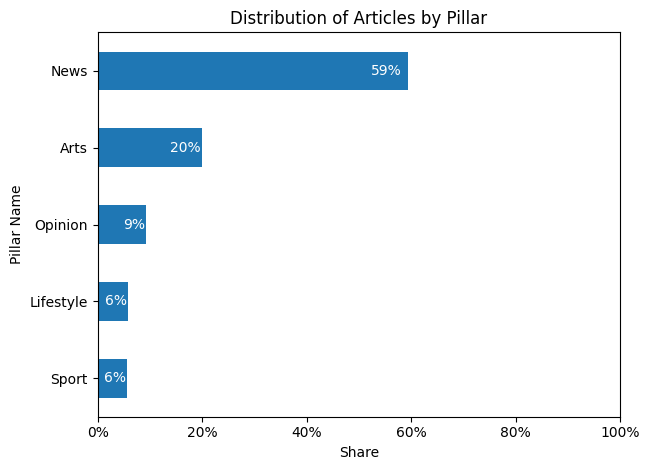

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Calculate shares
shares = df["pillarName"].value_counts(normalize=True, dropna=True)

# Sort for horizontal bar chart
shares = shares.sort_values()

plt.figure()
ax = shares.plot(kind="barh")

plt.xlabel("Share")
plt.ylabel("Pillar Name")
plt.title("Distribution of Articles by Pillar")


# data labels
for i, v in enumerate(shares):
    ax.text(
        v * 0.98,
        i,
        f"{v:.0%}",
        va="center",
        ha="right",
        color="white",
    )

plt.tight_layout()
# fixing a axis labels and limits
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 1)

plt.show()

In [17]:
# sorted(df["pillarName"].dropna().unique())
# df["sectionName"].nunique()

When analyzing the contents of our corpus by "pillar" or topic, we see that nearly six in ten (59%) of articles were published with the "News" classification. 20% were published with "Arts", 9% with "Opinion", and 6% with "Lifestyle" and "Sport" classifications. These represent all the present values for "pillarName" in the dataset.

Drilling down into the more granular category of "section", we see that there are many more unique values (84) for "sectionName" than there are for "pillarName" (There are 5 unique categories for "pillarName"). Below, we see that the only unique "sectionName" that represents over 10% of the articles in our corpus is "Technology", which accounts for 12% of articles. 

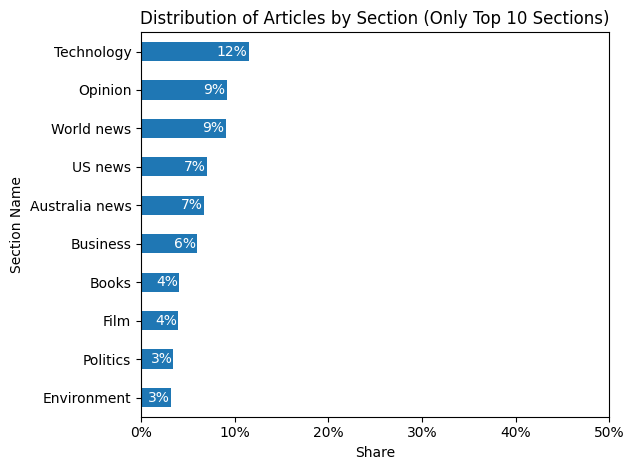

In [18]:
# Calculate shares
shares = (
    df["sectionName"].value_counts(normalize=True, dropna=True).head(10).sort_values()
)
# Sort for horizontal bar chart
shares = shares.sort_values().head(10)

plt.figure()
ax = shares.plot(kind="barh")

plt.xlabel("Share")
plt.ylabel("Section Name")
plt.title("Distribution of Articles by Section (Only Top 10 Sections)")


# data labels
for i, v in enumerate(shares):
    ax.text(
        v * 0.98,
        i,
        f"{v:.0%}",
        va="center",
        ha="right",
        color="white",
    )

plt.tight_layout()
# fixing a axis labels and limits
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 0.5)

plt.show()

In the figure below, we can see that after filtering our corpus to only articles under the "News" pillar, one in five (20%) of articles were assigned the "Technology" section name. None of the articles were assigned the section name of "Opinion", as "Opinion" pieces and "News" pieces (as categorized by pillar name or section name) were mutually exclusive categorizations. However, it was noteworthy that the mentions of "artificial intelligence" and "generative AI" were not solely concentrated among "News" articles published in the "Technology" section, but were present in a wide range of sections including categories that concerned geopolitical, environmental, economic, and societal topics. 

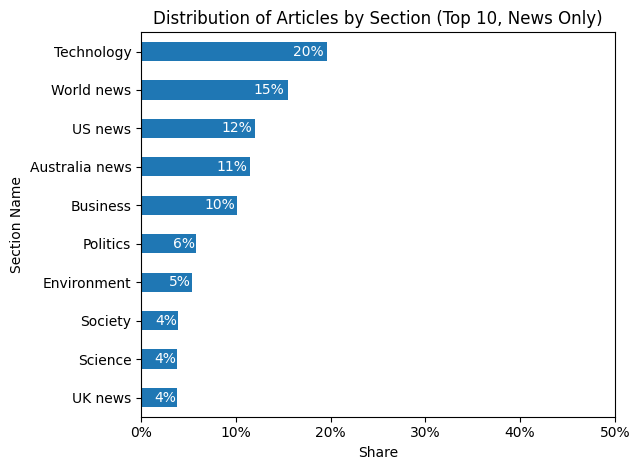

In [23]:
# Filter to News only
df_news = df[df["pillarName"] == "News"]

# Calculate shares (top 10 sections within News)
shares = (
    df_news["sectionName"]
    .value_counts(normalize=True, dropna=True)
    .head(10)
    .sort_values()
)

plt.figure()
ax = shares.plot(kind="barh")

plt.xlabel("Share")
plt.ylabel("Section Name")
plt.title("Distribution of Articles by Section (Top 10, News Only)")

# Data labels
for i, v in enumerate(shares):
    ax.text(
        v * 0.98,
        i,
        f"{v:.0%}",
        va="center",
        ha="right",
        color="white",
    )

plt.tight_layout()

# Format axis as percent and set limits
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 0.5)

plt.show()

When reviewing this corpus, it is informative to pay special attention to the distribution of articles concerning "artificial intelligence" and "generative AI" by the year in which they were published. In the below plot, we observe that there was a steady mention of articles concerning these technologies between 2016-2022 before a sharp increase in 2023 through 2025. 

This spike in mentions of artificial intelligence was likely due to the November 30, 2022 release of an early demo of ChatGPT by OpenAI (Forbes, 2023). Mentions of artificial intelligence and generative AI remained steady in 2024 before again increasing in 2025. As these terms have become salient topics in modern discussions of the economy, labor, environment, and society it is reasonable to expect that the 2026 number of mentions will be close to or exceed recent years. 

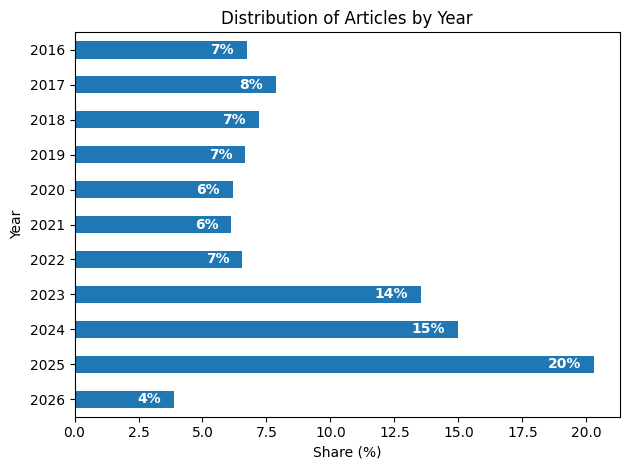

In [26]:
# plotting number of articles by year
df["webPublicationDate"] = pd.to_datetime(df["webPublicationDate"])
df["year"] = df["webPublicationDate"].dt.year
summary_year = df["year"].value_counts().sort_index(ascending=False).to_frame("Count")
summary_year["Share (%)"] = (
    summary_year["Count"] / summary_year["Count"].sum() * 100
).round(2)

plt.figure()
ax = summary_year["Share (%)"].plot(kind="barh")

plt.xlabel("Share (%)")
plt.ylabel("Year")
plt.title("Distribution of Articles by Year")

# data labels
for i, v in enumerate(summary_year["Share (%)"]):
    ax.text(
        v - 0.5,  # just inside the end of the bar
        i,
        f"{v:.0f}%",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
ax.set_xlim(0, summary_year["Share (%)"].max() * 1.05)
plt.show()

In [ ]:
# articles_by_year_term = (
#     df.groupby(["year", "search_term"])
#       .size()
#       .unstack(fill_value=0)
#       .sort_index()
# )

# articles_by_year_term

search_term,artificial intelligence,generative AI
year,,
2016,1017,608
2017,1220,676
2018,992,748
2019,932,680
2020,879,612
2021,814,666
2022,853,726
2023,1042,2219
2024,973,2638


One interesting difference can be seen when we facet the above plot by search term. In our corpus the distribution by year of articles with search term "artificial intelligence" is steady, with no clear pattern in variation. However, for articles with search term "generative AI", the distribution by year shows a much more marked increase in 2023, peaking in the most recent full year of articles (2025). This mirrors the above plot and shows that the more recent increase in articles that mention these topics is driven by "generative AI".

The term "artificial intelligence" was first used in the early 1950s by the computer scientist John McCarthy and his colleagues at the Dartmouth Conference (Haenlein & Kaplan 2019). Although generative AI concepts have existed since the development of generative neural networks in the early 2000s and the release of models such as the generative pre-trained transformer (or GPT) in 2018, this plot potentially indicates that this term may have been slightly more niche than artificial intelligence but is growing in popularity. 

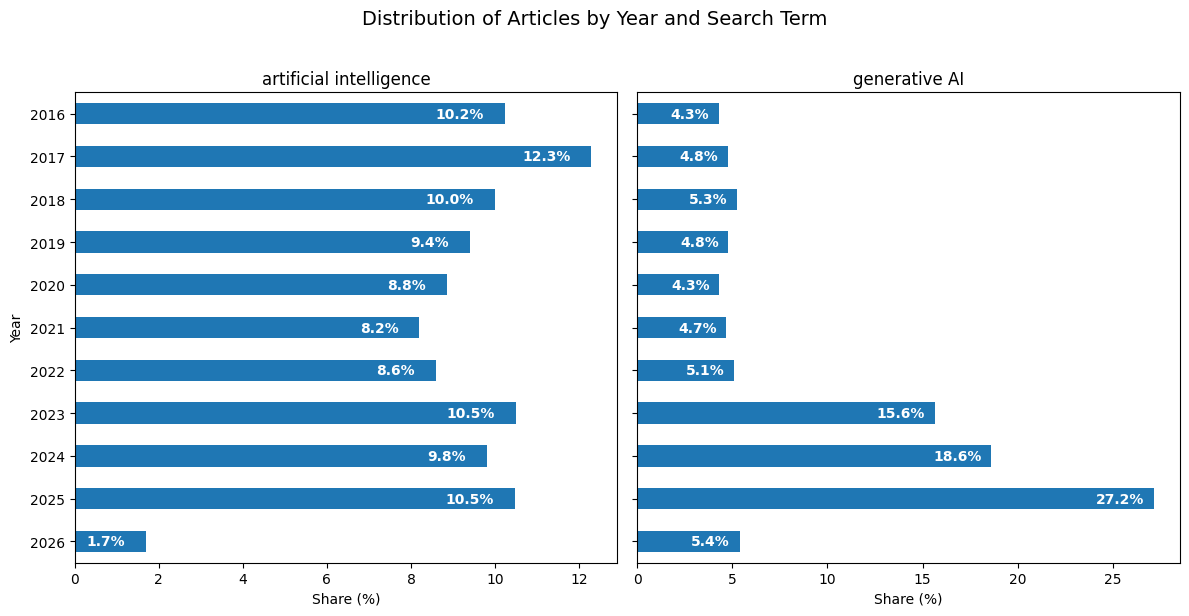

In [27]:
search_terms = df["search_term"].unique()
n = len(search_terms)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=True)

for ax, term in zip(axes, search_terms):
    subset = df[df["search_term"] == term]
    summary = (
        subset["year"].value_counts().sort_index(ascending=False).to_frame("Count")
    )
    summary["Share (%)"] = (summary["Count"] / summary["Count"].sum() * 100).round(2)

    summary["Share (%)"].plot(kind="barh", ax=ax)

    for i, v in enumerate(summary["Share (%)"]):
        ax.text(
            v - 0.5,
            i,
            f"{v:.1f}%",
            va="center",
            ha="right",
            color="white",
            fontweight="bold",
        )

    ax.set_title(term)
    ax.set_xlabel("Share (%)")
    ax.set_ylabel("Year")
    ax.set_xlim(0, summary["Share (%)"].max() * 1.05)

plt.suptitle("Distribution of Articles by Year and Search Term", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

<h2 id="measures-of-lexical-distinctiveness-similarity-and-syntactic-complexity">Measures of Lexical Distinctiveness, Similarity, and Syntactic Complexity</h2>

<h3 id="tf-idf-analysis">TF-IDF Analysis</h3>


Before conducting additional analysis on the corpus, I randomly sampled articles from the corpus to create a subset of 10 articles found using the search term "artificial intelligence" and 10 articles found using the search term "generative AI". The resulting 20 articles were saved in the `sample_articles` table in DuckDB. 

Used the `sklearn` package's `TfidfVectorizer` functionality. 
- used "english" stopwords


We can analyze the top 5 words per document by TF-IDF result. 

<h3 id="pearson-correlation">Pearson Correlation</h3>


In [ ]:
# pearson correlation

Write up details of Pearson Correlation results

<h3 id="syntactic-complexity-measures">Syntactic Complexity Measures</h3>


In [ ]:
# syntactic complexity measures

In [ ]:
# close connection to DuckDB
# con.close()

- talk about top five articles by MLS
- these seem to be the same as the top five articles with clauses per sentence, obivously because they have the longest sentences
- dependent clause per clause, dependent clause per sentence, coord per sentence
- complex nominals


<h2 id="synthesis-of-findings">Synthesis of Findings</h2>


Synthesis of Findings:
- This is a pretty complete dataset of articles. The lack of missingness of data makes it feasible for my purpose of building a query system with RAG functionality that is supplemented by additional feature engineering through Named Entity Recognition.

Research Question:
- TF-IDF summary (1 paragraph)
- Pearson Correlation (1 paragraph)
    - Many of the articles that write about artificial intelligence and generative AI come from the news and politics desks of the Guardian, particularly in news articles regarding the United States and the United Kingdom.
- Syntactic Complexity 

<h3 id="limitations-and-future-work">Limitations and Future Work</h3>

This analysis represents a limited exploration into the Guardian's overall corpus of news articles and publicly available content.  This analysis was limited to querying the Guardian API tool with the search terms "artificial intelligence" and "generative AI", although it is likely that some articles may have been missed that contain discussion of these and similar technologies but did not explicitly contain these keyword search terms. 

- only looked at a random sample of the large corpus, sampled 10 articles for each search term, there may be different findings when comparing articles by different qualities (authors, year published, sectionName). 
- Although some this analysis compared findings by search term, it is not yet clear that the decision to use "artificial intelligence" versus "generative AI" when writing about these technologies is accompanied by an intent to tell a different narrative or approach these technologies from a different paradigm. 


Future Direction:
- implement NER with BERT
- alow users to query the corpus by different features
- allow for RAG with LLM model so users can ask questions about artificial intelligence using natural language

<h3 id="appendix">Appendix</h3>


Guardian API Documentation: https://open-platform.theguardian.com/documentation/

References
https://bpb-us-w2.wpmucdn.com/sites.uab.edu/dist/6/536/files/2024/08/A-brief-history-of-AI.pdf

https://www.forbes.com/sites/bernardmarr/2023/05/19/a-short-history-of-chatgpt-how-we-got-to-where-we-are-today/